# Final Project: Predict Kyphosis

**Objective**: Build models to predict post-operative kyphosis (present vs absent) using Age (months), Number (vertebrae involved) and Start (topmost vertebra). Compare algorithms and select the best using an appropriate metric for class imbalance.



## LogisticRegression

In [15]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (confusion_matrix)

In [4]:
df = pd.read_excel('kyphosis.xlsx')
#df.drop(columns=['rownames'], inplace=True)
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [8]:
# quick EDA
print(df.shape)
df.columns
df.describe()
#df.info()

(81, 4)


,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


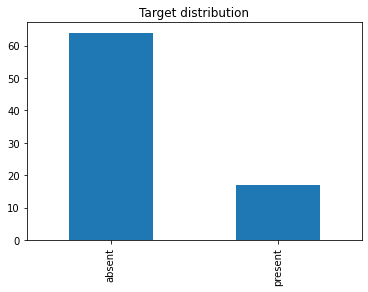

/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


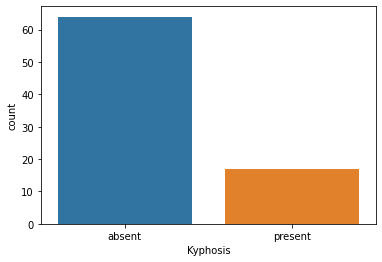

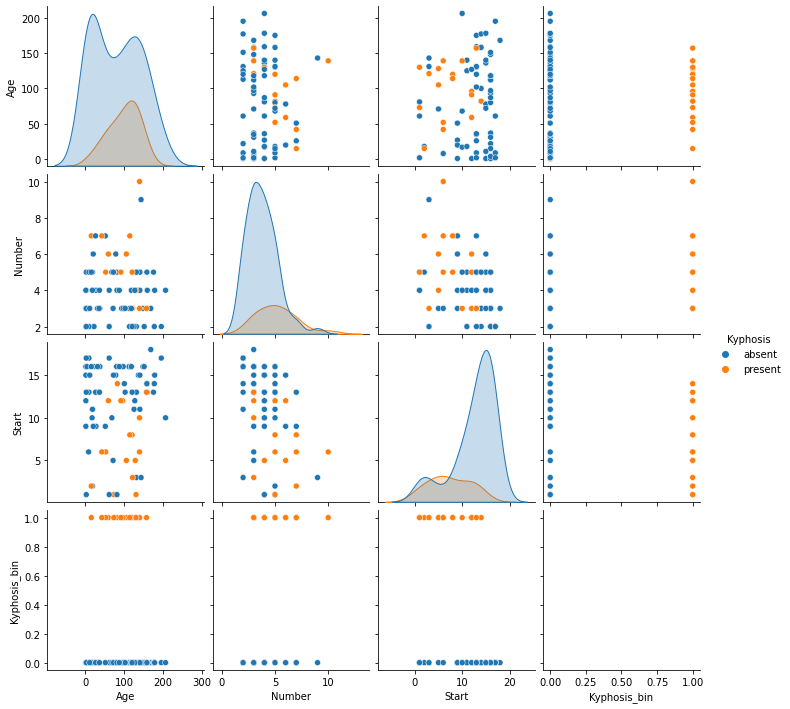

In [9]:
label_map = {'absent':0,'present':1}
df['Kyphosis_bin'] = df['Kyphosis'].map(label_map)
ax = df['Kyphosis'].value_counts().plot(kind='bar', title='Target distribution')
plt.show()
df.describe()
sns.countplot(x='Kyphosis', data=df)
sns.pairplot(df[['Age','Number','Start','Kyphosis']].assign(Kyphosis_bin=df['Kyphosis_bin']), hue='Kyphosis')
plt.show()

## Train/Test split and model candidates

In [10]:
X = df[['Age','Number','Start']]
y = df['Kyphosis_bin']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) # without randon state result varies in each run

In [11]:
# LogisticRegression
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
print(y_test.value_counts()) # total 17 records were used for test purpose

0    13
1     4
Name: Kyphosis_bin, dtype: int64


In [12]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8235294117647058
              precision    recall  f1-score   support

           0       0.81      1.00      0.90        13
           1       1.00      0.25      0.40         4

    accuracy                           0.82        17
   macro avg       0.91      0.62      0.65        17
weighted avg       0.86      0.82      0.78        17



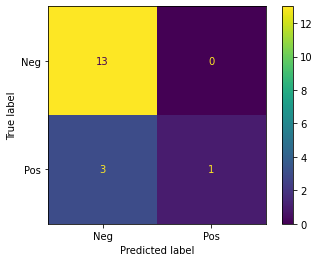

In [16]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neg', 'Pos'])
disp.plot()
plt.show()

## DecisionTree

In [17]:
dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print(y_test.value_counts()) # total 17 records were used for test purpose
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

0    13
1     4
Name: Kyphosis_bin, dtype: int64
Decision Tree Accuracy: 0.7647058823529411
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.50      0.25      0.33         4

    accuracy                           0.76        17
   macro avg       0.65      0.59      0.60        17
weighted avg       0.73      0.76      0.73        17



In [18]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(y_test.value_counts()) # total 17 records were used for test purpose
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

0    13
1     4
Name: Kyphosis_bin, dtype: int64
Decision Tree Accuracy: 0.8235294117647058
              precision    recall  f1-score   support

           0       0.81      1.00      0.90        13
           1       1.00      0.25      0.40         4

    accuracy                           0.82        17
   macro avg       0.91      0.62      0.65        17
weighted avg       0.86      0.82      0.78        17



In [19]:
dt2 = DecisionTreeClassifier(max_depth=7)

dt2.fit(X_train, y_train)
y_pred_dt2 = dt2.predict(X_test)
print(y_test.value_counts()) # total 17 records were used for test purpose
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt2))
print(classification_report(y_test, y_pred_dt2))

0    13
1     4
Name: Kyphosis_bin, dtype: int64
Decision Tree Accuracy: 0.8235294117647058
              precision    recall  f1-score   support

           0       0.81      1.00      0.90        13
           1       1.00      0.25      0.40         4

    accuracy                           0.82        17
   macro avg       0.91      0.62      0.65        17
weighted avg       0.86      0.82      0.78        17



## Random Forest

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) # without randon state result varies in each run
rf= RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90        13
           1       1.00      0.25      0.40         4

    accuracy                           0.82        17
   macro avg       0.91      0.62      0.65        17
weighted avg       0.86      0.82      0.78        17



In [21]:
# Random forst with Hyper Parameters
rf2 = RandomForestClassifier(n_estimators =300, max_depth =5)
rf2.fit(X_train, y_train)
y_pred_rf2 = rf2.predict(X_test)
print(classification_report(y_test, y_pred_rf2))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.50      0.25      0.33         4

    accuracy                           0.76        17
   macro avg       0.65      0.59      0.60        17
weighted avg       0.73      0.76      0.73        17



In [22]:
# Random forst with Hyper Parameters
rf2 = RandomForestClassifier(n_estimators =200, max_depth =5)
rf2.fit(X_train, y_train)
y_pred_rf2 = rf2.predict(X_test)
print(classification_report(y_test, y_pred_rf2))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.50      0.25      0.33         4

    accuracy                           0.76        17
   macro avg       0.65      0.59      0.60        17
weighted avg       0.73      0.76      0.73        17



## KNN

In [23]:
knn = KNeighborsClassifier(n_neighbors =7)
knn.fit(X_train, y_train)
y_pred_knn = rf.predict(X_test)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90        13
           1       1.00      0.25      0.40         4

    accuracy                           0.82        17
   macro avg       0.91      0.62      0.65        17
weighted avg       0.86      0.82      0.78        17



In [24]:
knn = KNeighborsClassifier(10)
knn.fit(X_train, y_train)
y_pred_knn = rf.predict(X_test)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90        13
           1       1.00      0.25      0.40         4

    accuracy                           0.82        17
   macro avg       0.91      0.62      0.65        17
weighted avg       0.86      0.82      0.78        17



## Gradient Boosting

In [25]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.79      0.85      0.81        13
           1       0.33      0.25      0.29         4

    accuracy                           0.71        17
   macro avg       0.56      0.55      0.55        17
weighted avg       0.68      0.71      0.69        17



## Naive Bayes

In [26]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print(classification_report(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89        13
           1       0.67      0.50      0.57         4

    accuracy                           0.82        17
   macro avg       0.76      0.71      0.73        17
weighted avg       0.81      0.82      0.81        17



In [27]:
#MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
print(classification_report(y_test, y_pred_mnb))

              precision    recall  f1-score   support

           0       0.89      0.62      0.73        13
           1       0.38      0.75      0.50         4

    accuracy                           0.65        17
   macro avg       0.63      0.68      0.61        17
weighted avg       0.77      0.65      0.67        17



## SVM Model

In [33]:
svm = SVC(kernel='rbf', class_weight='balanced')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.62      0.76        13
           1       0.44      1.00      0.62         4

    accuracy                           0.71        17
   macro avg       0.72      0.81      0.69        17
weighted avg       0.87      0.71      0.73        17



In [32]:
svm = SVC(kernel='linear', class_weight='balanced')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.91      0.77      0.83        13
           1       0.50      0.75      0.60         4

    accuracy                           0.76        17
   macro avg       0.70      0.76      0.72        17
weighted avg       0.81      0.76      0.78        17



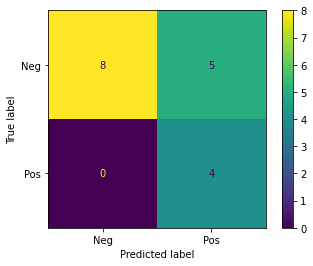

In [35]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neg', 'Pos'])
disp.plot()
plt.show()

## Conclusion

On Compring the models classification report, SVM model is best fit for this scenario as:
it has good recall of 76%
        
            